In [124]:
import pandas as pd
import numpy as np  
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [162]:

spatial_data_file = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/spatial_fingerprint_lidc_fgbg_malignancy_0_00_dropout_pu.csv")
#spatial_data_file = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/spatial_fingerprint_ADE20K_validation_deeplabv3_semantic_dropout_pu.csv")
spatial_data = pd.read_csv(spatial_data_file, index_col=0)
print(spatial_data.head())
print(spatial_data.columns)
print(len(spatial_data))

aggregated_data_file = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/aggregation_value_summary_lidc_fgbg_malignancy_0_00_dropout_pu.csv")
#aggregated_data_file = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/aggregation_value_summary_ADE20K_validation_deeplabv3_semantic_dropout_pu.csv")
aggregated_data = pd.read_csv(aggregated_data_file, index_col=0)
print(aggregated_data.head())
print(len(aggregated_data))

            moran   entropy       eds
0027_03  0.022847  0.465252  0.930062
0027_04  0.000398  0.389996  0.949855
0028_00  0.019711  0.562870  0.960811
0031_01  0.013786  0.455285  0.964707
0038_00  0.007587  0.428172  0.933175
Index(['moran', 'entropy', 'eds'], dtype='object')
105
                                     dataset_name      mean  \
uq_map_name                                                   
0027_03      lidc_fgbg_malignancy_0_00_dropout_pu  0.001731   
0027_04      lidc_fgbg_malignancy_0_00_dropout_pu  0.000828   
0028_00      lidc_fgbg_malignancy_0_00_dropout_pu  0.002445   
0031_01      lidc_fgbg_malignancy_0_00_dropout_pu  0.001193   
0038_00      lidc_fgbg_malignancy_0_00_dropout_pu  0.002832   

             above_threshold_mean_0.3  above_threshold_mean_0.5  \
uq_map_name                                                       
0027_03                      0.505600                  0.619659   
0027_04                      0.420001                  0.529599   
0028_00

In [163]:
data = pd.merge(spatial_data, aggregated_data, left_index=True, right_index=True)
data = data.drop(columns=['dataset_name'])

print(len(data))
print(data.columns)
print(data.dtypes)
data.head()

105
Index(['moran', 'entropy', 'eds', 'mean', 'above_threshold_mean_0.3',
       'above_threshold_mean_0.5', 'above_threshold_mean_0.7',
       'above_threshold_mean_0.9', 'above_threshold_mean_0.95',
       'above_quantile_mean_0.3', 'above_quantile_mean_0.5',
       'above_quantile_mean_0.7', 'above_quantile_mean_0.9',
       'above_quantile_mean_fg_ratio', 'patch_aggregation_10',
       'patch_aggregation_20', 'patch_aggregation_40', 'patch_aggregation_80',
       'patch_aggregation_100', 'class_mean_w_equal_weights',
       'class_mean_weighted_by_occurrence'],
      dtype='object')
moran                                float64
entropy                              float64
eds                                  float64
mean                                 float64
above_threshold_mean_0.3             float64
above_threshold_mean_0.5             float64
above_threshold_mean_0.7             float64
above_threshold_mean_0.9             float64
above_threshold_mean_0.95            float64
a

,moran,entropy,eds,mean,above_threshold_mean_0.3,above_threshold_mean_0.5,above_threshold_mean_0.7,above_threshold_mean_0.9,above_threshold_mean_0.95,above_quantile_mean_0.3,...,above_quantile_mean_0.7,above_quantile_mean_0.9,above_quantile_mean_fg_ratio,patch_aggregation_10,patch_aggregation_20,patch_aggregation_40,patch_aggregation_80,patch_aggregation_100,class_mean_w_equal_weights,class_mean_weighted_by_occurrence
0027_03,0.022847,0.465252,0.930062,0.001731,0.505600,0.619659,0.0,0.0,0.0,0.001731,...,0.005770,0.017295,0.179233,0.069079,0.017370,0.004432,0.001108,0.000709,0.128374,0.128374
0027_04,0.000398,0.389996,0.949855,0.000828,0.420001,0.529599,0.0,0.0,0.0,0.000828,...,0.002759,0.008269,0.120560,0.032469,0.008476,0.002119,0.000530,0.000339,0.058713,0.058713
0028_00,0.019711,0.562870,0.960811,0.002445,0.551237,0.621267,0.0,0.0,0.0,0.002445,...,0.008149,0.024426,0.285001,0.098506,0.024633,0.006259,0.001565,0.001001,0.105313,0.105313
0031_01,0.013786,0.455285,0.964707,0.001193,0.491222,0.575484,0.0,0.0,0.0,0.001193,...,0.003976,0.011919,0.186825,0.048847,0.012217,0.003054,0.000764,0.000489,0.129041,0.129041
0038_00,0.007587,0.428172,0.933175,0.002832,0.530217,0.636586,0.0,0.0,0.0,0.002832,...,0.009440,0.028297,0.181202,0.112732,0.028292,0.007162,0.001813,0.001160,0.104680,0.104680


In [164]:
corrs = data.corr()
# set values below diagonal to np.nan 
mask = np.tril(np.ones_like(corrs, dtype=bool))
#corrs[mask] = np.nan

#drop all rows except 'entropy' "moran' or "eds"
corrs = corrs.loc[[ 'moran', 'entropy', 'eds'], :]

In [140]:
corrs

,moran,entropy,eds,mean,above_threshold_mean_0.3,above_threshold_mean_0.5,above_threshold_mean_0.7,above_threshold_mean_0.9,above_threshold_mean_0.95,above_quantile_mean_0.3,...,above_quantile_mean_0.7,above_quantile_mean_0.9,patch_aggregation_10,patch_aggregation_20,patch_aggregation_40,patch_aggregation_80,patch_aggregation_100,patch_aggregation_200,class_mean_w_equal_weights,class_mean_weighted_by_occurrence
moran,1.000000,-0.820488,-0.826079,-0.026360,0.147329,0.267178,0.126563,0.027042,0.016451,-0.021892,...,0.011512,0.056528,0.350848,0.348173,0.352769,0.334535,0.326638,0.324395,0.088227,-0.026360
entropy,-0.820488,1.000000,0.893081,-0.007100,-0.095143,-0.172708,-0.092542,-0.038014,-0.023490,-0.007456,...,-0.024433,-0.050229,-0.265976,-0.273723,-0.289790,-0.281641,-0.275539,-0.278712,-0.071437,-0.007100
eds,-0.826079,0.893081,1.000000,0.061991,-0.060134,-0.154883,-0.070934,-0.024443,-0.015233,0.060742,...,0.038977,0.006677,-0.235277,-0.240534,-0.257777,-0.253034,-0.247557,-0.251225,-0.029075,0.061991


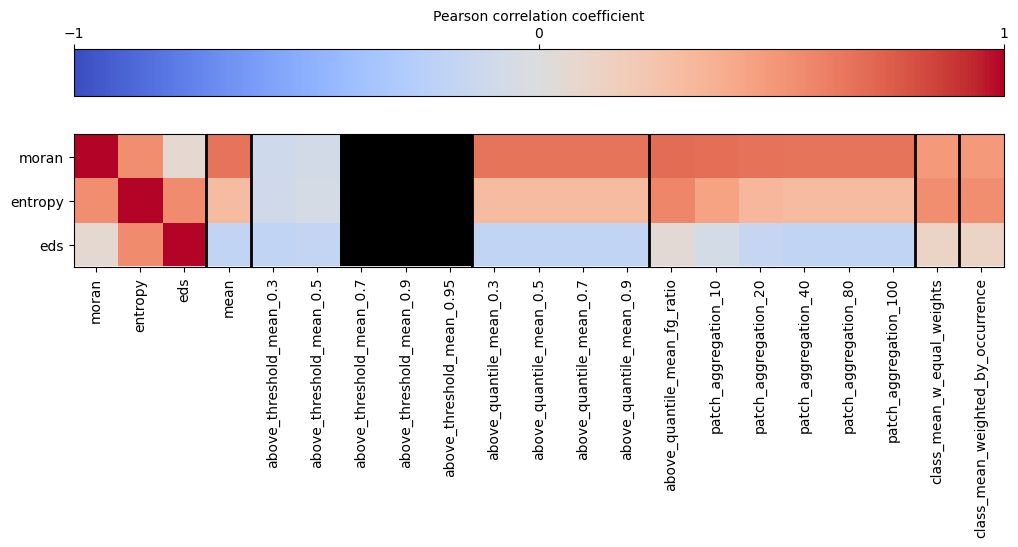

In [165]:

fig = plt.figure(figsize=(12, 10))
cmap = matplotlib.cm.coolwarm
cmap.set_bad('black')
im = plt.imshow(corrs, cmap=cmap, vmin=-1, vmax=1)
plt.xticks(ticks=np.arange(len(corrs.columns)), labels=corrs.columns, rotation=90)
plt.yticks(ticks=[0,1,2], labels=[ 'moran', 'entropy', 'eds'])
plt.hlines(xmin=-0.5, xmax=len(corrs.columns)-0.5, y = 2.5, color='white', linewidth=2)


plt.vlines(ymin=-0.5, ymax=2.5, x=2.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=3.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=8.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=12.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=18.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=19.5, color='black', linewidth=2)




fig.colorbar(im, location='top', ticks=[-1,  0,  1], label='Pearson correlation coefficient')
#plt.savefig()

<Axes: xlabel='entropy', ylabel='class_mean_w_equal_weights'>

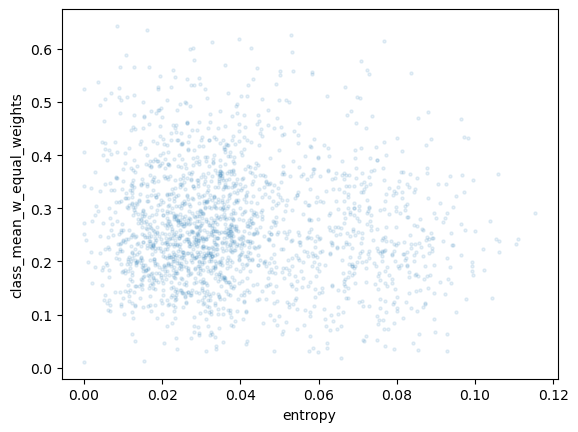

In [ ]:
#plt.yticks(ticks=np.arange(len(corrs.rows)), labels=corrs.rows)
# add gridlines around the minor ticks
#plt.grid(which='minor', color='white', linestyle='-', linewidth=0.5)


#plt.hlines(xmin=-0.5, xmax=len(corrs.columns)-0.5, y = 8.5, color='white', linewidth=2)
#plt.hlines(xmin=-0.5, xmax=len(corrs.columns)-0.5, y = 12.5, color='white', linewidth=2)
#plt.hlines(xmin=-0.5, xmax=len(corrs.columns)-0.5, y = 18.5, color='white', linewidth=2)
#plt.hlines(xmin=-0.5, xmax=len(corrs.columns)-0.5, y = 19.5, color='white', linewidth=2)#


plt.vlines(ymin=-0.5, ymax=len(corrs.columns)-0.5, x=2.5, color='white', linewidth=2)
plt.vlines(ymin=-0.5, ymax=len(corrs.columns)-0.5, x=3.5, color='white', linewidth=2)
plt.vlines(ymin=-0.5, ymax=len(corrs.columns)-0.5, x=8.5, color='white', linewidth=2)
plt.vlines(ymin=-0.5, ymax=len(corrs.columns)-0.5, x=12.5, color='white', linewidth=2)
plt.vlines(ymin=-0.5, ymax=len(corrs.columns)-0.5, x=18.5, color='white', linewidth=2)
plt.vlines(ymin=-0.5, ymax=len(corrs.columns)-0.5, x=19.5, color='white', linewidth=2)

plt.title("aggregation_value_summary_ADE20K_validation_deeplabv3_semantic_dropout_pu")
plt.savefig("CorrMatrix_aggregation_value_summary_ADE20K_validation_deeplabv3_semantic_dropout_pu.png", dpi=300, bbox_inches='tight')
plt.colorbar()


In [172]:
aggregated_data_file = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/aggregation_value_summary_ADE20K_validation_deeplabv3_semantic_dropout_pu.csv")
#aggregated_data_file = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/aggregation_value_summary_ADE20K_validation_deeplabv3_semantic_dropout_pu.csv")
aggregated_data = pd.read_csv(aggregated_data_file, index_col=0)
print(aggregated_data.head())
print(len(aggregated_data))
aggregated_data = aggregated_data.drop(columns=['dataset_name'])

                                                     dataset_name      mean  \
uq_map_name                                                                   
ADE_val_00000001  ADE20K_validation_deeplabv3_semantic_dropout_pu  0.075249   
ADE_val_00000002  ADE20K_validation_deeplabv3_semantic_dropout_pu  0.099919   
ADE_val_00000003  ADE20K_validation_deeplabv3_semantic_dropout_pu  0.130518   
ADE_val_00000004  ADE20K_validation_deeplabv3_semantic_dropout_pu  0.074909   
ADE_val_00000005  ADE20K_validation_deeplabv3_semantic_dropout_pu  0.053174   

                  above_threshold_mean_0.3  above_threshold_mean_0.5  \
uq_map_name                                                            
ADE_val_00000001                  0.381495                  0.525417   
ADE_val_00000002                  0.454676                  0.554505   
ADE_val_00000003                  0.395512                  0.550049   
ADE_val_00000004                  0.385964                  0.538224   
ADE_val_000000

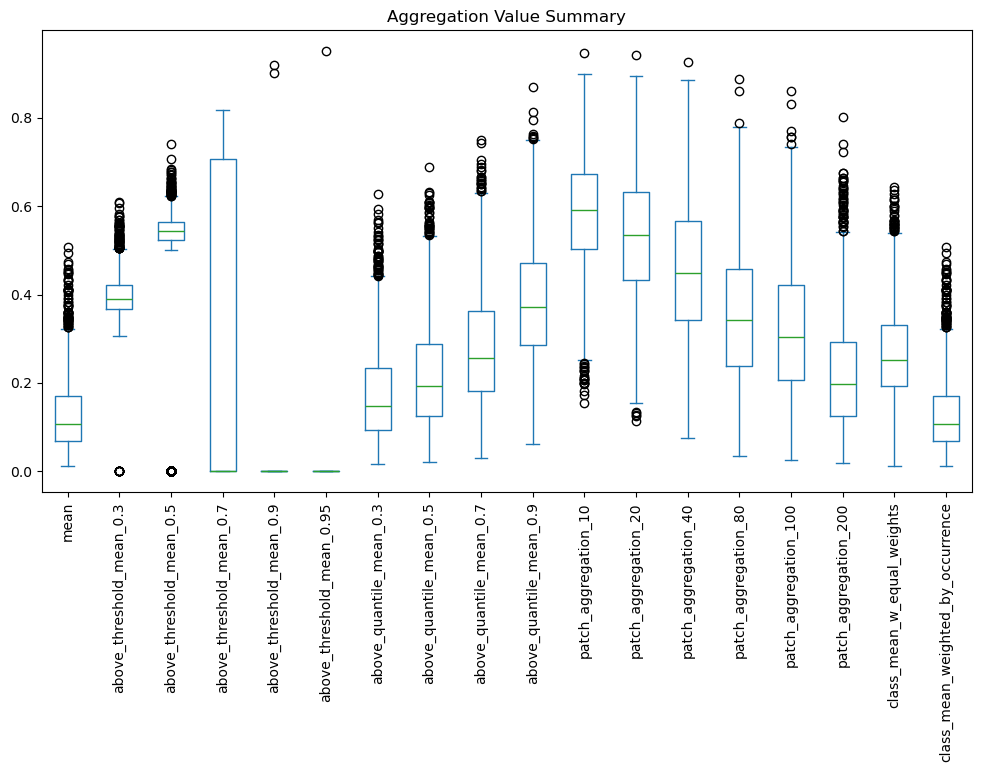

In [173]:
aggregated_data.plot(kind='box', figsize=(12, 6), title='Aggregation Value Summary')
plt.xticks(rotation=90  )
plt.show()


# spatial figerprint of ood vs id 

In [184]:
spatial_data_file_id = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/spatial_fingerprint_arctique_semantic_blood_cells_0_00_dropout_pu.csv")
spatial_data_id = pd.read_csv(spatial_data_file_id, index_col=0)
#rename colums by appending '_id' to the end of each column name
spatial_data_id.columns = [f"{col}_id" for col in spatial_data_id.columns]

spatial_data_file_ood = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/spatial_fingerprint_arctique_semantic_blood_cells_0_75_dropout_pu.csv")
spatial_data_ood = pd.read_csv(spatial_data_file_ood, index_col=0)
#rename colums by appending '_ood' to the end of each column name
spatial_data_ood.columns = [f"{col}_ood" for col in spatial_data_ood.columns]

In [187]:
data = pd.merge(spatial_data_id, spatial_data_ood, left_index=True, right_index=True)
#sort columns by name
data = data.reindex(sorted(data.columns), axis=1)
data.head()

,eds_id,eds_ood,entropy_id,entropy_ood,moran_id,moran_ood
308,0.386580,0.381185,0.019455,0.027005,0.210471,0.227432
235,0.336961,0.337676,0.004355,0.012461,0.207323,0.219629
309,0.363277,0.374162,0.014682,0.037486,0.217217,0.236419
254,0.412148,0.414171,0.012429,0.031792,0.202999,0.223104
312,0.389869,0.393152,0.011337,0.029995,0.206276,0.225903


<Axes: title={'center': 'Spatial Fingerprint Summary'}>

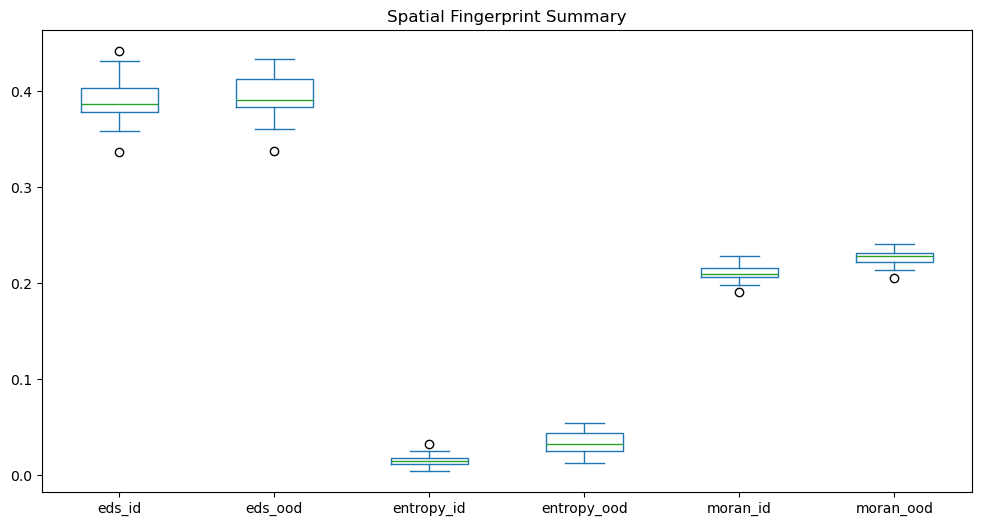

In [188]:
data.plot(kind='box', figsize=(12, 6), title='Spatial Fingerprint Summary')

In [225]:
spatial_data_file_id = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/spatial_fingerprint_lidc_fgbg_malignancy_0_00_dropout_pu.csv")
spatial_data_id = pd.read_csv(spatial_data_file_id, index_col=0)
spatial_data_id["mode"] = "id"
#rename colums by appending '_id' to the end of each column name
#spatial_data_id.columns = [f"{col}_id" for col in spatial_data_id.columns]

spatial_data_file_ood = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/spatial_fingerprint_lidc_fgbg_malignancy_1_00_dropout_pu.csv")
spatial_data_ood = pd.read_csv(spatial_data_file_ood, index_col=0)
spatial_data_ood["mode"] = "ood"
#rename colums by appending '_ood' to the end of each column name
#spatial_data_ood.columns = [f"{col}_ood" for col in spatial_data_ood.columns]

data = pd.concat([spatial_data_id, spatial_data_ood])
data = data.melt(id_vars=["mode"], value_vars=['moran', 'entropy', 'eds'], var_name='measure', value_name='value')

Text(0.5, 1.0, 'LIDC')

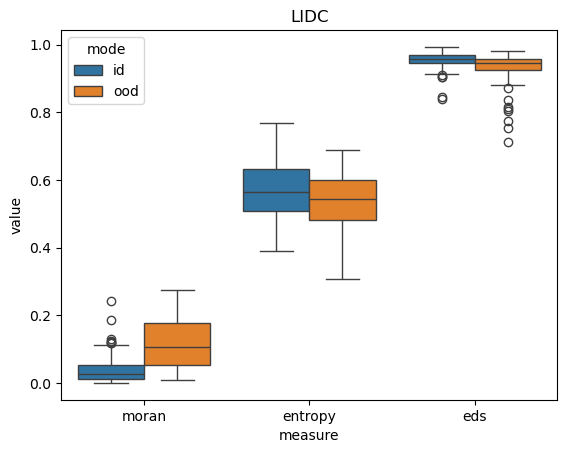

In [227]:

sns.boxplot(data=data, y='value', x='measure', hue='mode')
plt.title("LIDC")

In [256]:
spatial_files = ["spatial_fingerprint_lidc_fgbg_malignancy_0_00_dropout_pu.csv", 
                 "spatial_fingerprint_weedsgalore_dropout_pu.csv",
                 "spatial_fingerprint_cityscapes_dropout_pu.csv", 
                 "spatial_fingerprint_ADE20K_validation_deeplabv3_semantic_dropout_pu.csv", 
                 "spatial_fingerprint_arctique_semantic_blood_cells_0_00_dropout_pu.csv"]

aggregated_files = ["aggregation_value_summary_lidc_fgbg_malignancy_0_00_dropout_pu.csv", 
                    "aggregation_value_summary_weedsgalore_dropout_pu.csv",
                    "aggregation_value_summary_cityscapes_dropout_pu.csv",
                    "aggregation_value_summary_ADE20K_validation_deeplabv3_semantic_dropout_pu.csv", 
                    "aggregation_value_summary_arctique_semantic_blood_cells_0_00_dropout_pu.csv"]    

labels = ["LIDC", "WeedsGalore", "Cityscapes", "ADE20K", "Arctique"]

folder = Path("C:/Users/cwinklm/Documents/aggrigator_experiments/output/tables/")


dataframes = []

for label_idx, label in enumerate(labels):

    spatial_data = pd.read_csv(folder.joinpath(spatial_files[label_idx]), index_col=0)
    aggregated_data = pd.read_csv(folder.joinpath(aggregated_files[label_idx]), index_col=0)


    data = pd.merge(spatial_data, aggregated_data, left_index=True, right_index=True)
    data = data.drop(columns=['dataset_name'])
    data["label"] = label

    dataframes.append(data) 

data = pd.concat(dataframes, ignore_index=True)

In [254]:
data.columns

Index(['moran', 'entropy', 'eds', 'mean', 'above_threshold_mean_0.3',
       'above_threshold_mean_0.5', 'above_threshold_mean_0.7',
       'above_threshold_mean_0.9', 'above_threshold_mean_0.95',
       'above_quantile_mean_0.3', 'above_quantile_mean_0.5',
       'above_quantile_mean_0.7', 'above_quantile_mean_0.9',
       'above_quantile_mean_fg_ratio', 'patch_aggregation_10',
       'patch_aggregation_20', 'patch_aggregation_40', 'patch_aggregation_80',
       'patch_aggregation_100', 'class_mean_w_equal_weights',
       'class_mean_weighted_by_occurrence', 'label', 'patch_aggregation_200'],
      dtype='object')

<Axes: xlabel='entropy', ylabel='mean'>

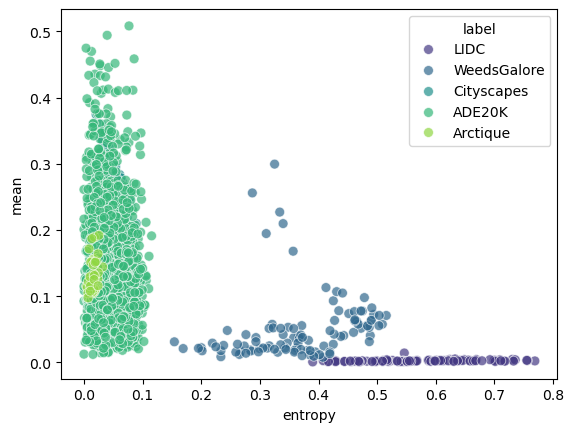

In [278]:
sns.scatterplot(data, x='entropy', y='mean', hue='label', palette='viridis', alpha=0.7, s=50)

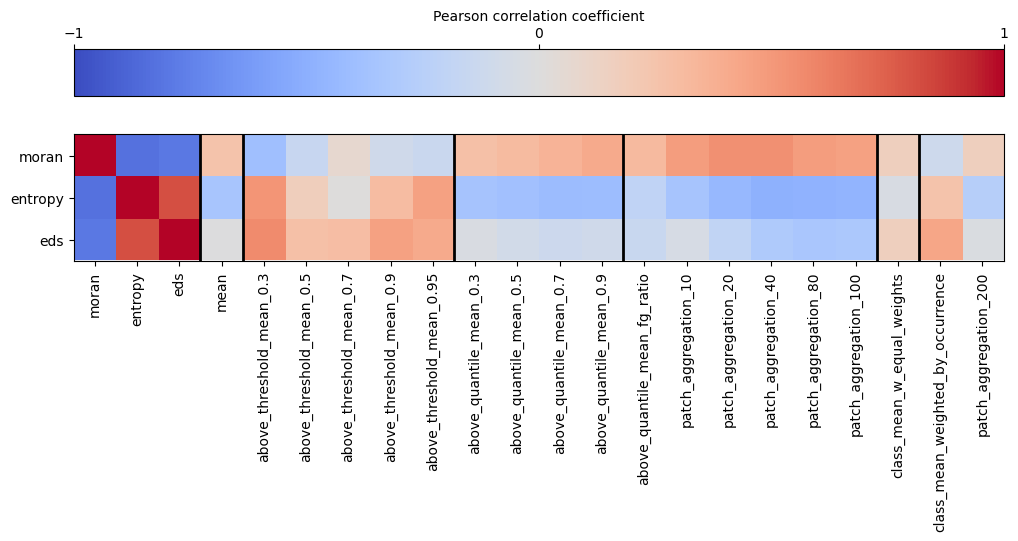

In [282]:
data_meas =  data.drop(columns=['label'])
corrs = data_meas.corr()    
corrs = corrs.loc[[ 'moran', 'entropy', 'eds'], :]

fig = plt.figure(figsize=(12, 10))
cmap = matplotlib.cm.coolwarm
cmap.set_bad('black')
im = plt.imshow(corrs, cmap=cmap, vmin=-1, vmax=1)
plt.xticks(ticks=np.arange(len(corrs.columns)), labels=corrs.columns, rotation=90)
plt.yticks(ticks=[0,1,2], labels=[ 'moran', 'entropy', 'eds'])
plt.hlines(xmin=-0.5, xmax=len(corrs.columns)-0.5, y = 2.5, color='white', linewidth=2)


plt.vlines(ymin=-0.5, ymax=2.5, x=2.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=3.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=8.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=12.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=18.5, color='black', linewidth=2)
plt.vlines(ymin=-0.5, ymax=2.5, x=19.5, color='black', linewidth=2)




fig.colorbar(im, location='top', ticks=[-1,  0,  1], label='Pearson correlation coefficient')
#plt.savefig()
